# 1. Setup and Data Downloading

In [3]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

os.environ["KERAS_BACKEND"] = "torch"
from keras import applications as ap
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.models import Sequential
from keras.optimizers import Adam
from keras.src.legacy.preprocessing.image import ImageDataGenerator

# If tensorflow is missing in this environment, run this once:
# %pip install tensorflow

In [4]:
# Prefer the actual local dataset already available on this machine.
local_dir = Path(r"C:\Users\a3197722\Downloads\archive\kagglecatsanddogs_3367a\PetImages")

if not local_dir.exists():
    local_dir = Path.cwd() / "kagglecatsanddogs_3367a" / "PetImages"

if not local_dir.exists():
    raise FileNotFoundError(f"Dataset folder not found. Checked: {local_dir}")

directory = os.path.abspath(str(local_dir))
print(f"Using dataset directory: {directory}")
print("Folder names:", sorted(p.name for p in local_dir.iterdir() if p.is_dir()))

Using dataset directory: /Users/sabyasachi/Documents/programming_forai_project_Proposal/kagglecatsanddogs_3367a/PetImages
Folder names: ['Cat', 'Dog']


In [5]:
os.listdir(directory)

['Cat', 'Dog']

# 2. Loading and Processing Data

In [6]:
images = []
labels = []

try:
    for foldr in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, foldr)
        if not os.path.isdir(class_dir):
            continue
        for filee in sorted(os.listdir(class_dir)):
            if filee.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(foldr, filee))
                labels.append(foldr)
except Exception as e:
    print(f'Error: {e}')

In [7]:
data = pd.DataFrame({
    'Images': images,
    'Labels': labels
})

# Clean the dataset before plotting or training.
data = data.dropna(subset=['Images', 'Labels']).copy()
data = data[data['Images'].str.lower().str.endswith(('.jpg', '.jpeg', '.png'))].copy()
data = data.drop_duplicates(subset=['Images']).reset_index(drop=True)

print('Total rows after cleaning:', len(data))
print('Duplicate rows:', data.duplicated(subset=['Images']).sum())
print('Missing values:\n', data.isna().sum())
print('Label distribution:\n', data['Labels'].value_counts())
print(data.head())


Total rows after cleaning: 24959
Duplicate rows: 0
Missing values:
 Images    0
Labels    0
dtype: int64
Label distribution:
 Labels
Cat    12490
Dog    12469
Name: count, dtype: int64
         Images Labels
0     Cat/0.jpg    Cat
1     Cat/1.jpg    Cat
2    Cat/10.jpg    Cat
3   Cat/100.jpg    Cat
4  Cat/1000.jpg    Cat


In [8]:
print('Dataset sample:')
print(data.head())
print('\nDataset tail:')
print(data.tail())
print(f'\nTotal images: {len(data)}')
print('\nClass distribution:')
print(data['Labels'].value_counts())

Dataset sample:
         Images Labels
0     Cat/0.jpg    Cat
1     Cat/1.jpg    Cat
2    Cat/10.jpg    Cat
3   Cat/100.jpg    Cat
4  Cat/1000.jpg    Cat

Dataset tail:
             Images Labels
24954  Dog/9995.jpg    Dog
24955  Dog/9996.jpg    Dog
24956  Dog/9997.jpg    Dog
24957  Dog/9998.jpg    Dog
24958  Dog/9999.jpg    Dog

Total images: 24959

Class distribution:
Labels
Cat    12490
Dog    12469
Name: count, dtype: int64


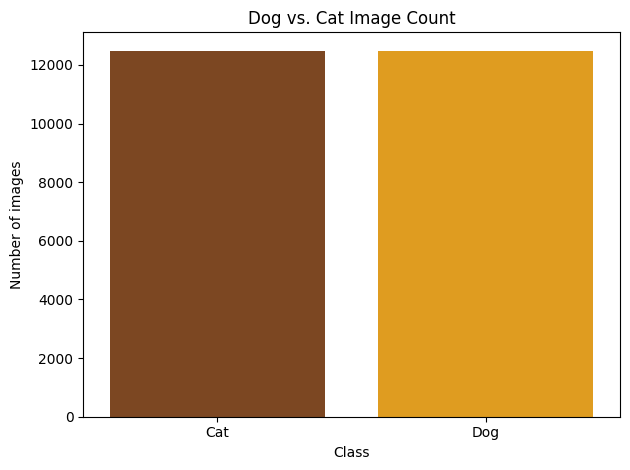

In [9]:
colors = ['#8B4513', 'orange']

sns.countplot(data=data, x='Labels', hue='Labels', palette=colors, dodge=False, legend=False)
plt.title('Dog vs. Cat Image Count')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Visualizing the Data
plotting one sample image from each category using OpenCV

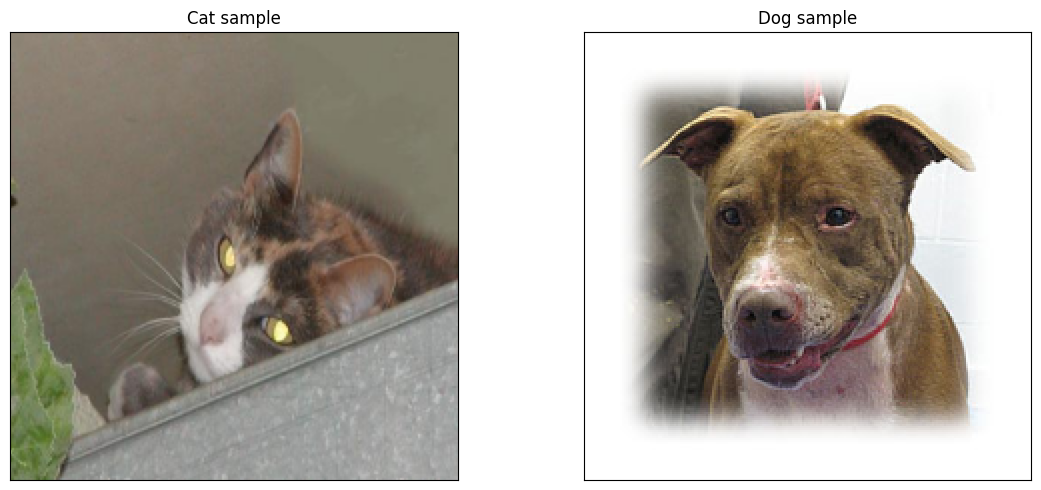

In [11]:
plt.figure(figsize=(12, 5))
classes = sorted(data['Labels'].unique())

for i, label in enumerate(classes):
    sample = data[data['Labels'] == label].sample(1).iloc[0]
    img_path = os.path.join(directory, sample['Images'])
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f'{label.capitalize()} sample', fontsize=12)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


# 4. Data Splitting

In [12]:
# Rebuild the DataFrame if it was cleared by a previous rerun.
if 'Images' not in locals() or data.empty:
    images = []
    labels = []
    for foldr in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, foldr)
        if not os.path.isdir(class_dir):
            continue
        for filee in sorted(os.listdir(class_dir)):
            if filee.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(foldr, filee))
                labels.append(foldr)
    data = pd.DataFrame({'Images': images, 'Labels': labels})
    data = data.dropna(subset=['Images', 'Labels']).copy()
    data = data[data['Images'].str.lower().str.endswith(('.jpg', '.jpeg', '.png'))].copy()
    data = data.drop_duplicates(subset=['Images']).reset_index(drop=True)

# Keep labels as strings for Keras ImageDataGenerator with binary class_mode.
data = data[data['Labels'].astype(str).str.strip().str.title().isin(['Cat', 'Dog'])].copy()
data['Labels'] = data['Labels'].astype(str).str.strip().str.title()

if len(data) == 0:
    raise ValueError('Dataset is empty. Check the dataset folder and run the loading cells again.')

if data['Labels'].isna().any():
    raise ValueError(f"Unexpected label values found: {data[data['Labels'].isna()]['Labels'].unique()}")

train_df, test_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['Labels'])

optimizer = Adam(learning_rate=0.0001)

print(f'Train set size: {len(train_df)}, Test set size: {len(test_df)}')
print('Label counts:')
print(data['Labels'].value_counts())


Train set size: 19967, Test set size: 4992
Label counts:
Labels
Cat    12490
Dog    12469
Name: count, dtype: int64


# 5. Data Augmentation

In [13]:
# Ensure the split DataFrame is valid before creating image batches.
if 'train_df' not in globals() or 'test_df' not in globals():
    raise ValueError('Run the data split cell before this augmentation cell.')

train_df = train_df.copy()
test_df = test_df.copy()

# Normalize labels so Keras sees strings, not numeric 0/1 left over from a rerun.
train_df['Labels'] = train_df['Labels'].astype(str).str.strip().str.title()
test_df['Labels'] = test_df['Labels'].astype(str).str.strip().str.title()

# If a stale run left 0/1 values, convert them back to Cat/Dog names.
train_df['Labels'] = train_df['Labels'].replace({'0': 'Cat', '1': 'Dog'})
test_df['Labels'] = test_df['Labels'].replace({'0': 'Cat', '1': 'Dog'})

trainimgen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
)

train_data = trainimgen.flow_from_dataframe(
    dataframe=train_df,
    directory=directory,
    x_col='Images',
    y_col='Labels',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=16,
)


Found 19967 validated image filenames belonging to 2 classes.


In [14]:
testimgen = ImageDataGenerator()


test_data = testimgen.flow_from_dataframe(
    dataframe=test_df,
    directory=directory,
    x_col='Images',
    y_col='Labels',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=16,
    shuffle=False # For test data, it's crucial to set shuffle=False. This ensures the prediction order matches the label order, which is necessary for correct evaluation with metrics like a confusion matrix.
)

Found 4992 validated image filenames belonging to 2 classes.


# 6. Building the Tranfer Learning (ResNet50) Model

In [21]:
# ResNet50 model
processing = ap.ResNet50(weights=None, include_top=False)

for layer in processing.layers[:5]:
    layer.trainable = False

Model = Sequential(
    [
        processing,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

In [24]:
Model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, None, None,     │    23,587,712 │
│                                 │ 2048)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 24,082,561 (91.87 MB)

 Non-trainable params: 62,720 (245.00 KB)

In [25]:
callbacky = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
Model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Model  Training

In [26]:
Model.fit(
    train_data,
    epochs=5,
    validation_data=test_data,
    callbacks=[callbacky]
    )

Epoch 1/5
   3/1248 ━━━━━━━━━━━━━━━━━━━━ 42:50:34 124s/step - accuracy: 0.5000 - loss: 0.7283

KeyboardInterrupt: 

# 8. Evaluating Model performance

In [14]:
Model.evaluate(test_data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9850 - loss: 0.0468


[0.04821445420384407, 0.9832000136375427]

In [ ]:
# Plotting a Confusion Matrix
preds = Model.predict(test_data)

# Converting probabilities to binary classes (0 or 1)
# The threshold 0.5 is standard for binary classification with a sigmoid activation
preds_classes = (preds > 0.5).astype(int).flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step


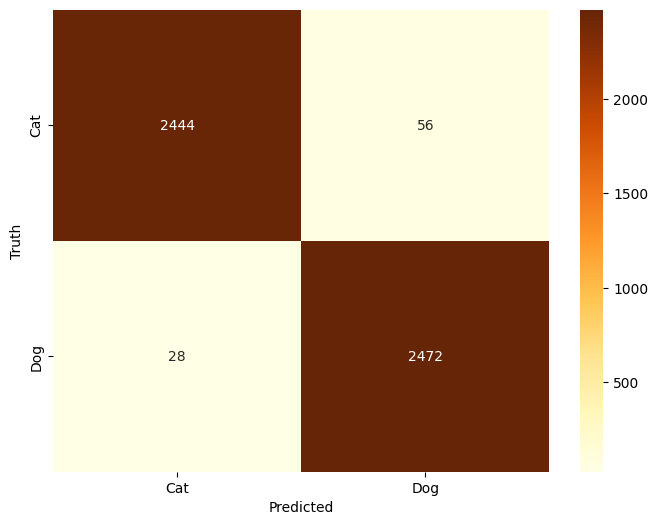

In [ ]:
true_labels = test_data.classes

cm = confusion_matrix(true_labels, preds_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=list(test_data.class_indices.keys()), 
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [19]:
Model.save('Resnet50 Model.h5')